In [1]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import h5py
import matplotlib.pyplot as plt
import os
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, roc_curve

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
print("PyTorch:", torch.__version__)

Mounted at /content/drive
Device: cuda
PyTorch: 2.10.0+cu128


In [2]:
file_path = '/content/drive/MyDrive/quark-gluon_data-set_n139306 (1).hdf5'
with h5py.File(file_path, 'r') as f:
    print("Shape:", f['X_jets'].shape)

Shape: (139306, 125, 125, 3)


In [3]:
def image_to_pointcloud(image, threshold=0.0):
    mask = np.any(image > threshold, axis=-1)
    coords = np.argwhere(mask)
    if len(coords) == 0:
        return np.zeros((1, 5), dtype=np.float32)
    x = coords[:, 0] / 124.0
    y = coords[:, 1] / 124.0
    ecal   = image[coords[:, 0], coords[:, 1], 0]
    hcal   = image[coords[:, 0], coords[:, 1], 1]
    tracks = image[coords[:, 0], coords[:, 1], 2]
    return np.stack([x, y, ecal, hcal, tracks], axis=1).astype(np.float32)

In [4]:
class JetGraphDataset(Dataset):
    def __init__(self, X_pc, y):
        self.X = torch.tensor(X_pc, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [9]:
print("Loading data...")
with h5py.File(file_path, 'r') as f:
    X_data = f['X_jets'][:20000]
    y_data = f['y'][:20000]
print(f"Loaded: {X_data.shape}")

# Pre-process in chunks
print("Pre-processing...")
MAX_NODES = 100
X_pc = np.zeros((len(X_data), MAX_NODES, 5), dtype=np.float32)

for i in range(len(X_data)):
    pc = image_to_pointcloud(X_data[i])
    if len(pc) > MAX_NODES:
        energy = pc[:, 2] + pc[:, 3] + pc[:, 4]
        pc = pc[np.argsort(energy)[-MAX_NODES:]]
    pad = MAX_NODES - len(pc)
    if pad > 0:
        pc = np.vstack([pc, np.zeros((pad, 5), dtype=np.float32)])
    X_pc[i] = pc
    if i % 5000 == 0:
        print(f"  {i}/{len(X_data)}")

# Free original data immediately
del X_data
import gc
gc.collect()
print(f"Done! Shape: {X_pc.shape}")

# Create datasets
indices = np.random.permutation(20000)
train_idx = indices[:16000]
val_idx   = indices[16000:]

train_ds = JetGraphDataset(X_pc[train_idx], y_data[train_idx])
val_ds   = JetGraphDataset(X_pc[val_idx],   y_data[val_idx])

# Free X_pc after dataset creation
del X_pc
gc.collect()

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Loading data...
Loaded: (20000, 125, 125, 3)
Pre-processing...
  0/20000
  5000/20000
  10000/20000
  15000/20000
Done! Shape: (20000, 100, 5)
Train: 16000 | Val: 4000


In [10]:
class GNNClassifier(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=128):
        super(GNNClassifier, self).__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )
        self.lin1 = nn.Linear(hidden_dim, hidden_dim)
        self.bn1  = nn.BatchNorm1d(hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, hidden_dim)
        self.bn2  = nn.BatchNorm1d(hidden_dim)
        self.lin3 = nn.Linear(hidden_dim, hidden_dim)
        self.bn3  = nn.BatchNorm1d(hidden_dim)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        B, N, _ = x.shape
        x = self.input_proj(x.view(B*N, -1)).view(B, N, -1)
        x = F.relu(self.bn1(self.lin1(x.view(B*N, -1)))).view(B, N, -1)
        x = F.relu(self.bn2(self.lin2(x.view(B*N, -1)))).view(B, N, -1)
        x = F.relu(self.bn3(self.lin3(x.view(B*N, -1)))).view(B, N, -1)
        mean_pool = x.mean(dim=1)
        max_pool  = x.max(dim=1).values
        return self.classifier(torch.cat([mean_pool, max_pool], dim=-1)).squeeze(-1)

model_gnn = GNNClassifier(input_dim=5, hidden_dim=128).to(device)
print(f"Parameters: {sum(p.numel() for p in model_gnn.parameters()):,}")

Parameters: 92,545


In [11]:
criterion = nn.BCEWithLogitsLoss()

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        loss = criterion(model(X), y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            total_loss += criterion(logits, y).item()
            all_preds.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return total_loss/len(loader), roc_auc_score(all_labels, all_preds), all_preds, all_labels

In [13]:
optimizer = torch.optim.Adam(model_gnn.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

num_epochs = 30
val_aucs = []

for epoch in range(num_epochs):
    tl = train_epoch(model_gnn, train_loader, optimizer)
    vl, auc, _, _ = eval_epoch(model_gnn, val_loader)
    val_aucs.append(auc)
    scheduler.step()
    print(f"Epoch [{epoch+1:2d}/{num_epochs}] | Loss: {tl:.4f} | Val Loss: {vl:.4f} | AUC: {auc:.4f}")

print("\nDone!")

Epoch [ 1/30] | Loss: 0.5529 | Val Loss: 0.6382 | AUC: 0.7818
Epoch [ 2/30] | Loss: 0.5497 | Val Loss: 1.0054 | AUC: 0.7466
Epoch [ 3/30] | Loss: 0.5518 | Val Loss: 0.5996 | AUC: 0.7821
Epoch [ 4/30] | Loss: 0.5494 | Val Loss: 0.5598 | AUC: 0.7851
Epoch [ 5/30] | Loss: 0.5488 | Val Loss: 0.9338 | AUC: 0.7565
Epoch [ 6/30] | Loss: 0.5490 | Val Loss: 0.5820 | AUC: 0.7818
Epoch [ 7/30] | Loss: 0.5472 | Val Loss: 0.5596 | AUC: 0.7855
Epoch [ 8/30] | Loss: 0.5477 | Val Loss: 0.5617 | AUC: 0.7856
Epoch [ 9/30] | Loss: 0.5471 | Val Loss: 1.0110 | AUC: 0.7483
Epoch [10/30] | Loss: 0.5460 | Val Loss: 0.5934 | AUC: 0.7824
Epoch [11/30] | Loss: 0.5455 | Val Loss: 0.5989 | AUC: 0.7830
Epoch [12/30] | Loss: 0.5421 | Val Loss: 0.5596 | AUC: 0.7851
Epoch [13/30] | Loss: 0.5424 | Val Loss: 0.5635 | AUC: 0.7844
Epoch [14/30] | Loss: 0.5418 | Val Loss: 0.5628 | AUC: 0.7848
Epoch [15/30] | Loss: 0.5402 | Val Loss: 1.0058 | AUC: 0.7533
Epoch [16/30] | Loss: 0.5402 | Val Loss: 0.5845 | AUC: 0.7836
Epoch [1

In [17]:
model_gnn = GNNClassifier(input_dim=5, hidden_dim=128).to(device)
optimizer = torch.optim.Adam(model_gnn.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

best_auc = 0
num_epochs = 30
val_aucs = []

for epoch in range(num_epochs):
    tl = train_epoch(model_gnn, train_loader, optimizer)
    vl, auc, _, _ = eval_epoch(model_gnn, val_loader)
    val_aucs.append(auc)
    scheduler.step(auc)
    if auc > best_auc:
        best_auc = auc
        torch.save(model_gnn.state_dict(), '/content/Genie-Task/common_task2_gnn/best_gnn.pth')
    print(f"Epoch [{epoch+1:2d}/{num_epochs}] | Loss: {tl:.4f} | AUC: {auc:.4f} {'★' if auc == best_auc else ''}")

model_gnn.load_state_dict(torch.load('/content/Genie-Task/common_task2_gnn/best_gnn.pth'))
print(f"\nBest AUC: {best_auc:.4f}")

Epoch [ 1/30] | Loss: 0.6316 | AUC: 0.7324 ★
Epoch [ 2/30] | Loss: 0.6118 | AUC: 0.7549 ★
Epoch [ 3/30] | Loss: 0.5963 | AUC: 0.7643 ★
Epoch [ 4/30] | Loss: 0.5865 | AUC: 0.7704 ★
Epoch [ 5/30] | Loss: 0.5841 | AUC: 0.7750 ★
Epoch [ 6/30] | Loss: 0.5775 | AUC: 0.7739 
Epoch [ 7/30] | Loss: 0.5706 | AUC: 0.7787 ★
Epoch [ 8/30] | Loss: 0.5672 | AUC: 0.7798 ★
Epoch [ 9/30] | Loss: 0.5732 | AUC: 0.7778 
Epoch [10/30] | Loss: 0.5637 | AUC: 0.7720 
Epoch [11/30] | Loss: 0.5646 | AUC: 0.7742 
Epoch [12/30] | Loss: 0.5625 | AUC: 0.7616 
Epoch [13/30] | Loss: 0.5586 | AUC: 0.7831 ★
Epoch [14/30] | Loss: 0.5540 | AUC: 0.7626 
Epoch [15/30] | Loss: 0.5526 | AUC: 0.7840 ★
Epoch [16/30] | Loss: 0.5518 | AUC: 0.7759 
Epoch [17/30] | Loss: 0.5504 | AUC: 0.7584 
Epoch [18/30] | Loss: 0.5522 | AUC: 0.7683 
Epoch [19/30] | Loss: 0.5500 | AUC: 0.7848 ★
Epoch [20/30] | Loss: 0.5500 | AUC: 0.7840 
Epoch [21/30] | Loss: 0.5505 | AUC: 0.7818 
Epoch [22/30] | Loss: 0.5487 | AUC: 0.7861 ★
Epoch [23/30] | Loss:

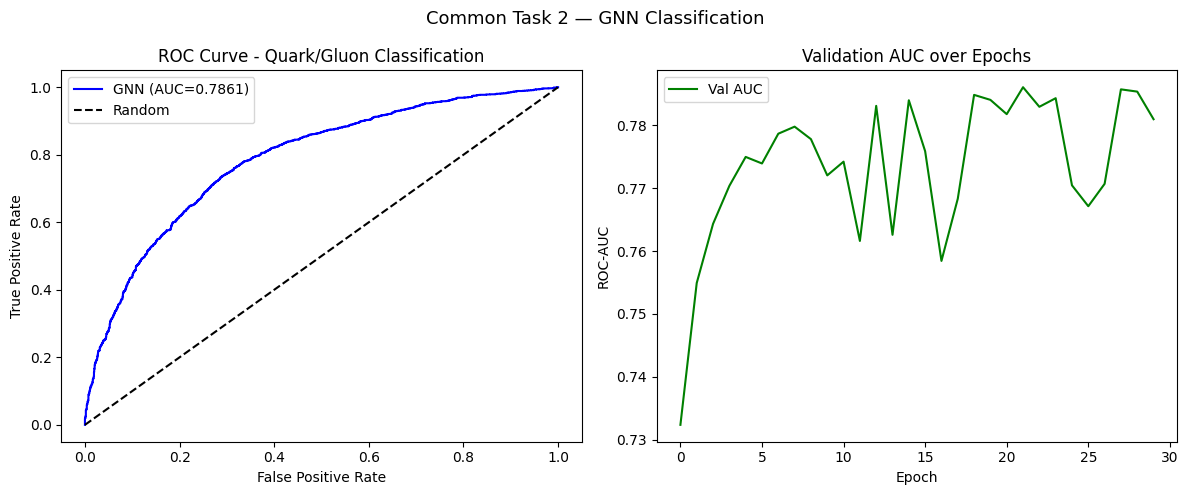

Final AUC: 0.7861


In [18]:
model_gnn.load_state_dict(torch.load('/content/Genie-Task/common_task2_gnn/best_gnn.pth'))
_, final_auc, preds, labels = eval_epoch(model_gnn, val_loader)
fpr, tpr, _ = roc_curve(labels, preds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(fpr, tpr, label=f'GNN (AUC={final_auc:.4f})', color='blue')
ax1.plot([0,1],[0,1],'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve - Quark/Gluon Classification')
ax1.legend()

ax2.plot(val_aucs, color='green', label='Val AUC')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('ROC-AUC')
ax2.set_title('Validation AUC over Epochs')
ax2.legend()

plt.suptitle('Common Task 2 — GNN Classification', fontsize=13)
plt.tight_layout()
plt.savefig('/content/Genie-Task/common_task2_gnn/Task2_result.png', dpi=150)
plt.show()
print(f"Final AUC: {final_auc:.4f}")